# Six-band U-Net MobileNetV2: test metrics and predictions

Load `best_unet_mobilenet_v2_6bands.pt`, evaluate the full test split from
`datasetsetup.py`, then display satellite RGB, ground truth, and prediction
using the same Pillow layout as `test_unet_pillow.ipynb`.

Run the cells in order from the project directory with the project Python environment.
The split uses the training seed and current dataset/split settings: reproducing the
original training test set requires these to remain unchanged.


In [1]:
from pathlib import Path
import numpy as np
import torch
from IPython.display import display
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from datasetsetup import create_datasets
from train import RANDOM_SEED, run_epoch
from train_unet_mobilenet_v2_6bands import (
    CHECKPOINT_PATH, DECODER_CHANNELS, ENCODER_DEPTH, ENCODER_NAME,
    INPUT_BANDS, NUM_INPUT_CHANNELS, UNetMobileNetV2SixBands,
)

N_IMAGES = 5
BATCH_SIZE = 8
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT_PATH}')

/home/emanuele/progetti/LandWaterSeg/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Checkpoint: /home/emanuele/progetti/LandWaterSeg/best_unet_mobilenet_v2_6bands.pt


In [2]:
checkpoint_path = Path(CHECKPOINT_PATH)
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
expected_metadata = {
    'architecture': 'smp.Unet',
    'encoder_name': ENCODER_NAME,
    'encoder_depth': ENCODER_DEPTH,
    'decoder_channels': DECODER_CHANNELS,
    'input_channels': NUM_INPUT_CHANNELS,
    'input_bands': INPUT_BANDS,
}
for key, expected in expected_metadata.items():
    actual = checkpoint.get(key)
    normalized = tuple(actual) if isinstance(expected, tuple) and actual is not None else actual
    if normalized != expected:
        raise ValueError(
            f'Incompatible checkpoint for {key}: {actual!r}; expected {expected!r}. '
            'Run train_unet_mobilenet_v2_6bands.py to regenerate it.'
        )

model = UNetMobileNetV2SixBands().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'], strict=True)
model.eval()
print(f"Model loaded from epoch {checkpoint.get('epoch', '?')}")
print(f"Input bands: {', '.join(INPUT_BANDS)}")
del checkpoint



Model loaded from epoch 18
Input bands: B02, B03, B04, B08, B11, B12


## Recreate the test split
Only the test dataset is evaluated, without augmentation or shuffling.


In [3]:
# Reuse exactly the dataset preparation and seed used by the training script.
_, _, dataset = create_datasets(seed=RANDOM_SEED)
if len(dataset) == 0:
    raise RuntimeError('The test split is empty')
test_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)
print(f'Test samples: {len(dataset)}')
print(f'Split seed: {RANDOM_SEED}')


Maschere non valide escluse: 1703/28224
Test samples: 5231
Split seed: 42


## Metrics on the complete test set
Accuracy covers both classes. IoU, precision, recall, and Dice treat water (1)
as the positive class. Counts are aggregated over all test pixels, rather than
averaging per-image scores. Predictions use `argmax`, as in training; zero
denominators produce a score of 0, following the shared metric implementation.


In [4]:
# No optimizer is supplied: run_epoch performs evaluation without gradients.
test_metrics = run_epoch(model, test_loader, DEVICE, description='Full test set')
print('\nBest checkpoint — full test set metrics')
for label, key in (
    ('Accuracy (acc)', 'accuracy'),
    ('IoU', 'iou'),
    ('Precision', 'precision'),
    ('Recall', 'recall'),
    ('Dice score', 'dice'),
):
    print(f'{label:<16}: {test_metrics[key]:.4f}')



Best checkpoint — full test set metrics
Accuracy (acc)  : 0.9851
IoU             : 0.9488
Precision       : 0.9633
Recall          : 0.9844
Dice score      : 0.9737


## Visual comparison
Show up to `N_IMAGES` random test samples. RGB uses B04, B03, B02 with a
percentile stretch for display only; inference uses all six normalized bands.
Black = land, blue = water. Rerun the following cell for another random selection.


Sample #1996: S2A_MSIL2A_20190331T155221_N0211_R111_T17MNT_20190331T224544_14_29
Sample #3596: S2B_MSIL2A_20200207T113309_N0214_R080_T28PCA_20200207T132518_10_32
Sample #4275: S2B_MSIL2A_20200207T113309_N0214_R080_T28PCA_20200207T132518_25_6
Sample #5134: S2B_MSIL2A_20200207T113309_N0214_R080_T28PCA_20200207T132518_7_35
Sample #613: S2A_MSIL2A_20171120T101321_N0206_R022_T32TQR_20171120T122503_22_31


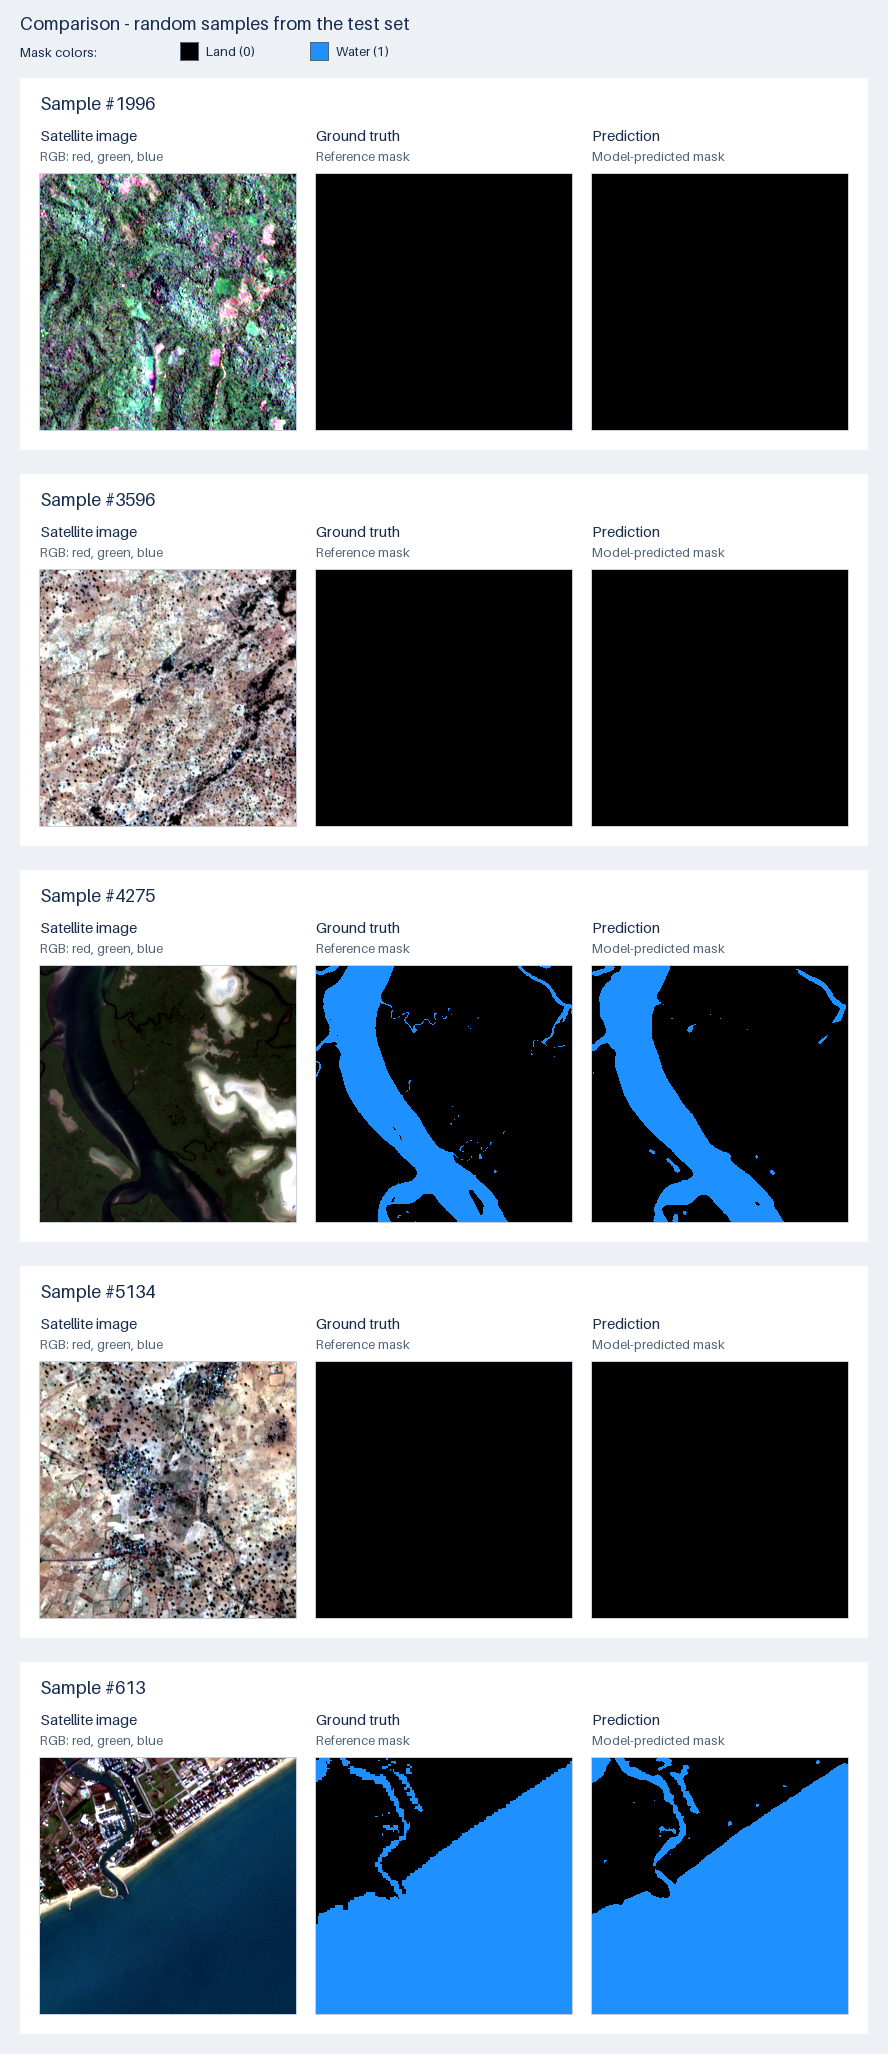

In [5]:
from PIL import ImageFont


def rgb_image(tensor):
    """Create a display-only RGB composite with a 2–98 percentile stretch."""
    # The first bands are B02, B03, B04; RGB requires B04, B03, B02.
    rgb = tensor[[2, 1, 0]].permute(1, 2, 0).cpu().numpy()
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    rgb = np.clip((rgb - low) / np.maximum(high - low, 1e-6), 0, 1)
    return Image.fromarray((rgb * 255).astype(np.uint8))


def mask_image(mask):
    """Render land in black and water in blue."""
    values = mask.cpu().numpy().astype(bool)
    output = np.zeros((*values.shape, 3), dtype=np.uint8)
    output[values] = (30, 144, 255)
    return Image.fromarray(output)


# Visualization settings (pixels).
PANEL_GAP = 20
ROW_GAP = 24
OUTER_PADDING = 20
BACKGROUND = '#edf1f5'
TEXT_COLOR = '#172b4d'
WATER_COLOR = (30, 144, 255)
TITLE_FONT = ImageFont.load_default(size=18)
LABEL_FONT = ImageFont.load_default(size=15)
DETAIL_FONT = ImageFont.load_default(size=13)

if N_IMAGES <= 0:
    raise ValueError('N_IMAGES must be greater than zero')
# Select test samples without duplicates; rerun this cell for a new selection.
indices = np.random.default_rng().permutation(len(dataset)).tolist()
count = min(N_IMAGES, len(dataset))
rows = []
model.eval()

with torch.inference_mode():
    for index in indices:
        image, target = dataset[index]
        probabilities, _ = model(image.unsqueeze(0).to(DEVICE))
        prediction = probabilities.argmax(dim=1)[0].cpu()
        panels = [rgb_image(image), mask_image(target), mask_image(prediction)]
        width, height = panels[0].size
        header_height = 96
        row_width = 2 * OUTER_PADDING + 3 * width + 2 * PANEL_GAP
        row = Image.new('RGB', (row_width, header_height + height + OUTER_PADDING), 'white')
        draw = ImageDraw.Draw(row)
        draw.text((OUTER_PADDING, 14), f'Sample #{index}', font=TITLE_FONT, fill=TEXT_COLOR)
        labels = [
            ('Satellite image', 'RGB: red, green, blue'),
            ('Ground truth', 'Reference mask'),
            ('Prediction', 'Model-predicted mask'),
        ]
        for column, (panel, (title, subtitle)) in enumerate(zip(panels, labels)):
            x = OUTER_PADDING + column * (width + PANEL_GAP)
            draw.text((x, 48), title, font=LABEL_FONT, fill=TEXT_COLOR)
            draw.text((x, 70), subtitle, font=DETAIL_FONT, fill='#526477')
            row.paste(panel, (x, header_height))
            draw.rectangle(
                (x - 1, header_height - 1, x + width, header_height + height),
                outline='#c7d0db',
            )
        rows.append(row)
        print(f"Sample #{index}: {dataset.pairs.iloc[index]['sample_id']}")
        if len(rows) == count:
            break

if not rows:
    raise RuntimeError('No valid samples to display')
if len(rows) < count:
    print(f'Only {len(rows)} valid samples are available')

legend_height = 78
canvas = Image.new(
    'RGB',
    (rows[0].width + 2 * OUTER_PADDING,
     legend_height + sum(row.height for row in rows) + ROW_GAP * (len(rows) - 1) + OUTER_PADDING),
    BACKGROUND,
)
legend = ImageDraw.Draw(canvas)
legend.text((OUTER_PADDING, 12), 'Comparison - random samples from the test set', font=TITLE_FONT, fill=TEXT_COLOR)
legend.text((OUTER_PADDING, 44), 'Mask colors:', font=DETAIL_FONT, fill=TEXT_COLOR)
for x, color, label in ((180, (0, 0, 0), 'Land (0)'), (310, WATER_COLOR, 'Water (1)')):
    legend.rectangle((x, 42, x + 18, 60), fill=color, outline='#526477')
    legend.text((x + 26, 43), label, font=DETAIL_FONT, fill=TEXT_COLOR)
offset = legend_height
for row in rows:
    canvas.paste(row, (OUTER_PADDING, offset))
    offset += row.height + ROW_GAP
display(canvas)
